In [1]:
import os
import shutil
import zipfile
from glob import glob
from dataclasses import dataclass

import cv2
import requests
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

from torchvision.utils import make_grid

# for data augumentation and preprocessing
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [2]:
# To download and unzip processed dataset.

def download_and_unzip(url, save_path):
    file = requests.get(url)
    open(save_path, "wb").write(file.content)

    try:
        with zipfile.ZipFile(save_path) as z:
            z.extractall(os.path.split(save_path)[0]) # Unzip where downloaded.
            print("Extracted all")
    except:
        print("Invalid file")

In [3]:
URL = r"https://www.dropbox.com/s/ckwxi6arhunzr9h/dataset_SUIM.zip?dl=1"

dataset_name = "dataset_SUIM"
dataset_zip_path = os.path.join(os.getcwd(), f"{dataset_name}.zip")
dataset_path = os.path.join(os.getcwd(), dataset_name)

# Download if dataset does not exists.
if not os.path.exists(dataset_path):
    download_and_unzip(URL, dataset_zip_path)
    # shutil.rmtree(dataset_zip_path) # Remove the ZIP file to free storage space.

In [4]:
@dataclass(frozen=True)
class DatasetConfig:
    NUM_CLASSES: int = 6
    IMG_WIDTH:   int = 256
    IMG_HEIGHT:  int = 256

    DATA_TRAIN_IMAGES: str = os.path.join(dataset_path, "train", "images", r"*.jpg")
    DATA_TRAIN_LABELS: str = os.path.join(dataset_path, "train", "masks",  r"*.bmp")
    DATA_VALID_IMAGES: str = os.path.join(dataset_path, "valid", "images", r"*.jpg")
    DATA_VALID_LABELS: str = os.path.join(dataset_path, "valid", "masks",  r"*.bmp")
    DATA_TEST_IMAGES:  str = os.path.join(dataset_path, "test",  "images", r"*.jpg")
    DATA_TEST_LABELS:  str = os.path.join(dataset_path, "test",  "masks",  r"*.bmp")

In [5]:
class CustomSegDataset(Dataset):
    def __init__(self, *, 
                 image_size, num_classes, 
                 image_paths, mask_paths = None, 
                 is_train = False):
                 self.image_size = image_size
                 self.num_classes = num_classes
                 self.image_paths = image_paths
                 self.mask_paths = mask_paths
                 self.is_train = is_train
                 self.transforms = self.setup_transforms()
    
    def __len__(self):
        return len(self.image_paths)

    def setup_transforms(self):
        transforms = []
        if self.is_train:
            transforms.extend([
                A.HorizontalFlip(p=0.5),
                A.ShiftScaleRotate(scale_limit = 0.1, 
                                   rotate_limit = 0.2, 
                                   shift_limit = 0.2, 
                                   p = 0.5, 
                                   border_mode = 0)
            ])
        transforms.extend([
            A.Normalize(mean = [0.485, 0.456, 0.406], 
                        std = [0.229, 0.224, 0.225], always_apply = True),
            ToTensorV2()
        ])

        return A.Compose(transforms)
    
    def load_file(self, 
                  file_path, 
                  interpolation = cv2.INTER_NEAREST):

        file = cv2.imread(file_path, 
                          cv2.IMREAD_COLOR)[:,:,::-1]
        file = cv2.resize(file, 
                          self.image_size, 
                          interpolation = interpolation)

        return file

    def __getitem__(self, index):
        # get image and mask path
        image_path = self.image_paths[index]
        # load image
        image = self.load_file(image_path, 
                               interpolation = cv2.INTER_CUBIC)

        if self.mask_paths is not None:
            mask_path = self.mask_paths[index]
            # load mask
            mask = self.load_file(mask_path, 
                                  interpolation = cv2.INTER_NEAREST)

            # convert mask to single channel mask
            mask = rgb_to_grayscale(mask)

            # apply transforms to image and mask
            transformed = self.transforms(image = image, mask = mask)
            image, mask = transformed['image'], transformed['mask'].to(torch.long)

            return image, mask

        else: # for test set
            # apply preprocessing transforms to image
            transformed = self.transforms(image = image)
            image = transformed['image']

            return image


In [6]:
id2color = {
    0: (0,  0,    0),    # BW: Background/waterbody
    1: (0,  0,    255),  # HD: Human divers
    2: (0,  255,  255),  # WR: Wrecks and ruins
    3: (255, 0,   0),    # RO: Robots and instruments
    4: (255, 0,   255),  # RI: Reefs and invertebartes
    5: (255, 255, 0),    # FV: Fish and vertebrates
 }

 #Reverse id2color mapping
 # used for converting RGB mask to single channel(grayscale) representation
 
rev_id2color = {value:key for key,value in id2color.items()} 

In [7]:
# Function to convert RGB mask to grayscale labels
def rgb_to_grayscale(rgb_arr, color_map = rev_id2color):
    # Collapse H,W dimensions
    reshaped_rgb_arr = rgb_arr.reshape((-1,3))
    # Get an array of all unique pixels along with the "inverse" array
    # (of the same shape as the original array) filled with indices to the unique array.
    # Each value in the "inverse" array points to the unique pixel at that
    # location in the input array.
    unique_pixels, inverse = np.unique(reshaped_rgb_arr, 
                                       axis = 0, 
                                       return_inverse = True)
    # If unique pixel is not found in color_map, class ID of background pixel is used
    # here background pixel class ID is 0
    grayscale_map = np.array([color_map.get(tuple(pixel), 0) for pixel in unique_pixels])[inverse]
    return grayscale_map.reshape(rgb_arr.shape[:2])

In [8]:
# function to convert grayscale labels to RGB mask
def num_to_rgb(num_arr, color_map = id2color):
    single_layer = np.squeeze(num_arr)
    output = np.zeros(num_arr.shape[:2] + (3,))

    for k in color_map.keys():
        output[single_layer == k] = color_map[k]

    return np.float32(output)/255.0

In [9]:
# funtion to overlay segmentation map on top of an RGB image
def image_overlay(image, segmented_image):
    alpha = 1.0 # transparency for original image
    beta = 0.7 # transparency for segmentation map
    gamma = 0.0 # scalar added to each sum

    segmented_image = cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR)

    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    image = cv2.addWeighted(image, alpha, segmented_image, beta, gamma, image)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return np.clip(image, 0.0, 1.0)

In [10]:
def display_image_and_mask(*, images, masks, 
                           color_mask = False, 
                           color_map = id2color):
    title = ['Image', 'Mask', 'overlay mask']

    for idx in range(images.shape[0]):
        image = images[idx]
        grayscale_gt_mask = masks[idx]

        plt.figure(figsize = (15,5))
        
        # Create RGB segmentation map from grayscale segmentation map.
        rgb_gt_mask = num_to_rgb(grayscale_gt_mask, color_map=color_map)

        # Create the overlayed image.
        overlayed_image = image_overlay(image, rgb_gt_mask)

        # Plot image, segmentation map and overlayed image.
        plt.subplot(1, 3, 1)
        plt.title(title[0])
        plt.imshow(image)
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.title(title[1])
        if color_mask:
            plt.imshow(rgb_gt_mask)
        else:
            plt.imshow(grayscale_gt_mask)
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.title(title[2])
        plt.imshow(overlayed_image)
        plt.axis('off')

        plt.show()
        plt.close()
    return
                        


In [11]:
# creating dataloader objects
def get_dataloader(batch_size = 4, 
                   num_workers = 0, 
                   pin_memory = False):

    NUM_CLASSES = DatasetConfig.NUM_CLASSES

    IMAGE_SIZE = (DatasetConfig.IMG_WIDTH, DatasetConfig.IMG_HEIGHT)

    # training image and mask paths
    train_images = sorted(glob(f"{DatasetConfig.DATA_TRAIN_IMAGES}"))
    train_masks = sorted(glob(f"{DatasetConfig.DATA_TRAIN_LABELS}"))

    # validation image and mask paths
    valid_images = sorted(glob(f"{DatasetConfig.DATA_VALID_IMAGES}"))
    valid_masks = sorted(glob(f"{DatasetConfig.DATA_VALID_LABELS}"))

    # test image and mask paths
    test_images = sorted(glob(f"{DatasetConfig.DATA_TEST_IMAGES}"))
    test_masks = None

    # create training dataset and dataloader
    train_dataset = CustomSegDataset(
        image_paths = train_images,
        mask_paths = train_masks,
        is_train = True,
        num_classes = NUM_CLASSES,
        image_size = IMAGE_SIZE
    )
    train_loader = DataLoader(train_dataset,
                              batch_size = batch_size, 
                              pin_memory = pin_memory, 
                              num_workers = num_workers, 
                              shuffle = True)

    # create validation dataset and dataloader
    valid_dataset = CustomSegDataset(
        image_paths = valid_images,
        mask_paths = valid_masks,
        is_train = False,
        num_classes = NUM_CLASSES,
        image_size = IMAGE_SIZE
    )

    valid_loader = DataLoader(valid_dataset, 
                              batch_size = batch_size, 
                              pin_memory = pin_memory, 
                              num_workers = num_workers, 
                              shuffle = False)

    # create test dataset and dataloader
    test_dataset = CustomSegDataset(
        image_paths = test_images,
        mask_paths = test_masks,
        is_train = False,
        num_classes = NUM_CLASSES,
        image_size = IMAGE_SIZE
    )
    test_loader = DataLoader(test_dataset, 
                             batch_size = batch_size, 
                             pin_memory = pin_memory, 
                             num_workers = num_workers, 
                             shuffle = False)

    return train_loader, valid_loader, test_loader

In [12]:
train_loader, valid_loader, test_loader = get_dataloader()

/Users/suryasaikadali/Downloads/open_Cv/DLPT2_practise/dlpt2_env/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/var/folders/mw/91f7xgx1617g6jpg31x48ncr0000gn/T/ipykernel_40274/3876789787.py:28: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  A.Normalize(mean = [0.485, 0.456, 0.406],


In [13]:
# display sample images from dataset

def denormalize(tensors, mean = (0.485, 0.456, 0.406), std = (0.229, 0.224, 0.225)):
    """
    Denormalizes a batch of images that were normalized using the given mean and std.
    
    Args:
        tensors (torch.Tensor): A batch of normalized images with shape (B, C, H, W).
        mean (tuple): The mean used for normalization (default is ImageNet mean).
        std (tuple): The standard deviation used for normalization (default is ImageNet std).
        """
    for c in range(3):
        tensors[:, c, :, :].mul_(std[c]).add_(mean[c])
    return torch.clamp(tensors, min = 0.0, max = 1.0)

    

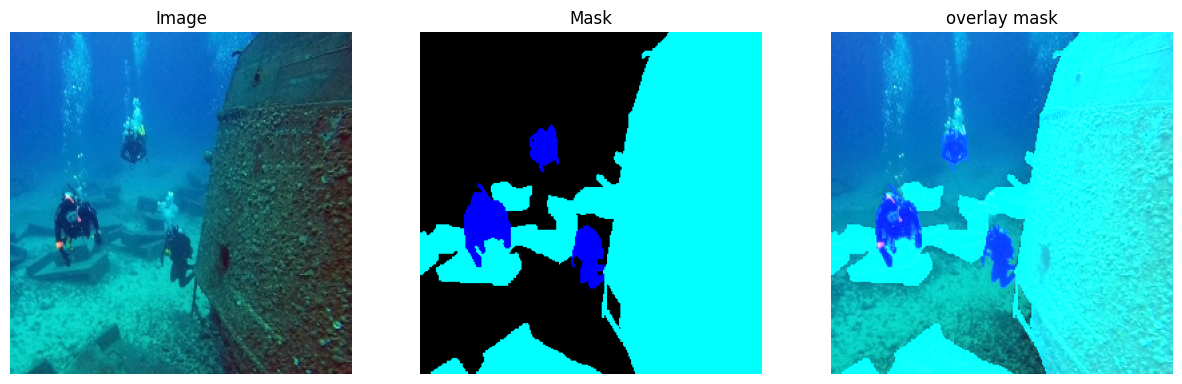

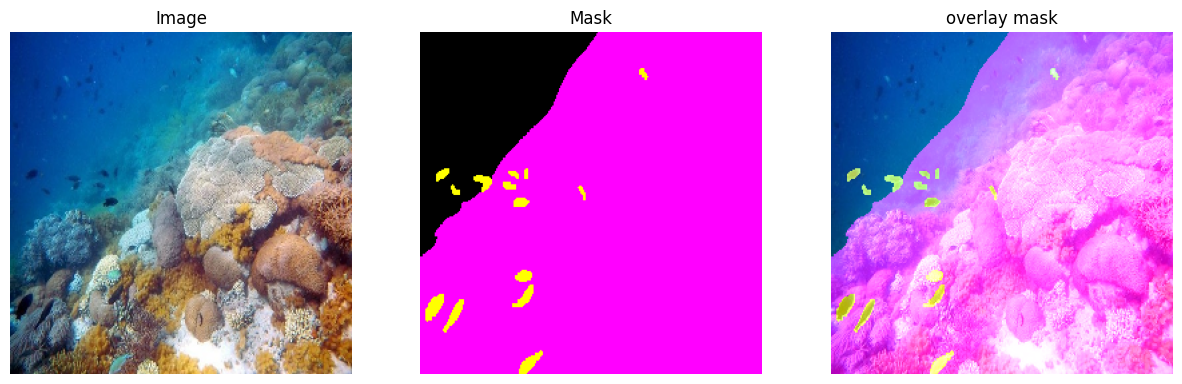

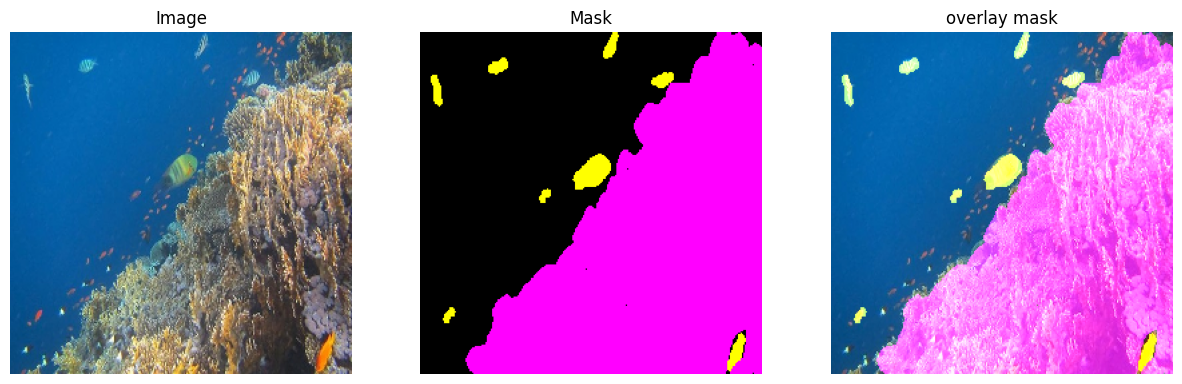

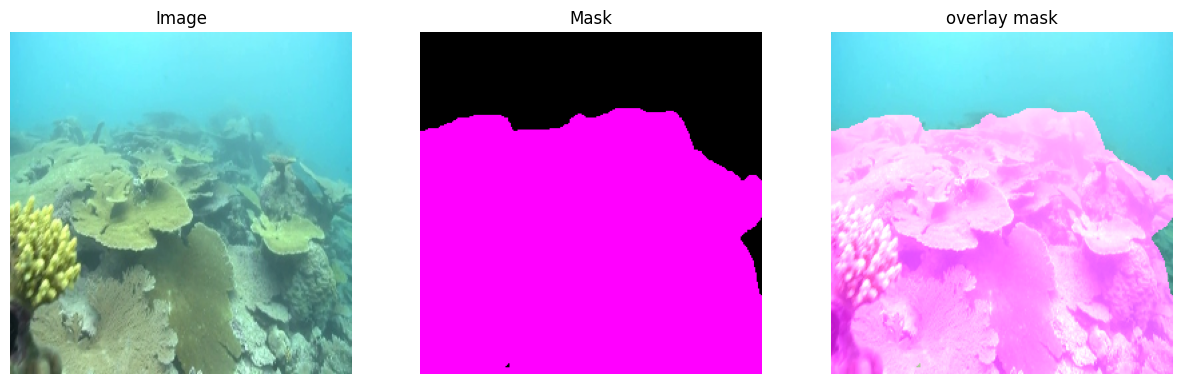

In [14]:
for batch_images, batch_masks in valid_loader:
        batch_images = denormalize(batch_images).permute(0,2,3,1).numpy()
        batch_masks = batch_masks.numpy()

        display_image_and_mask(images = batch_images, 
                               masks = batch_masks, 
                               color_mask = True)

        break

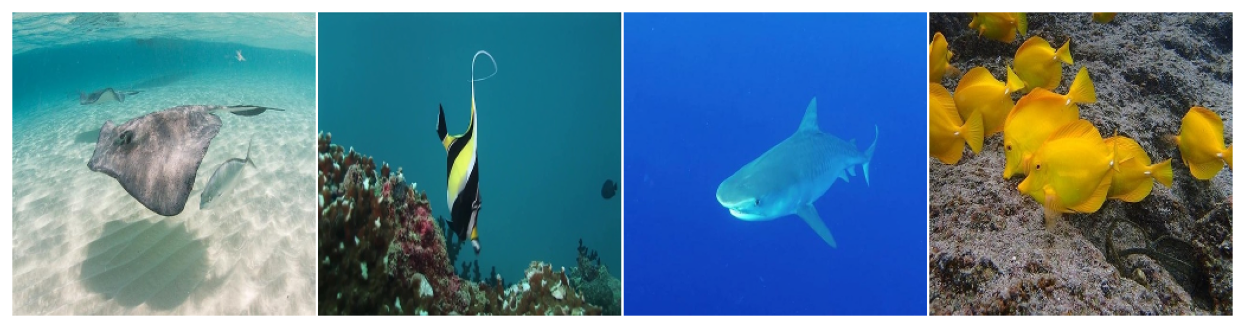

In [15]:
for batch_images in test_loader:

    batch_images = denormalize(batch_images)

    grid = make_grid(batch_images, nrow=batch_images.shape[0], padding=2,  pad_value= 1.0).permute(1, 2, 0).numpy()

    plt.figure(figsize=(16, 4))
    plt.imshow(grid)
    plt.axis('off')

    break